 (1) 用 Pandas 快速統計每個類別（資料夾）有幾張圖片並繪圖

In [15]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from shutil import copy2

In [16]:
# ==== 路徑設定 ====
# DATA_DIR = "./datasets"                 # 本地端總資料夾
RAW_DIR  = Path(DATA_DIR) / "pokemon"
TARGET_CLASSES = {"mimikyu", "pikachu"}  # 只想看的類別

# 影像與訓練參數
IMG_SIZE = (224, 224)
BATCH   = 32
EPOCHS  = 20
SEED    = 42

各類別圖片數量：


,count
class,
mimikyu,100
pikachu,100


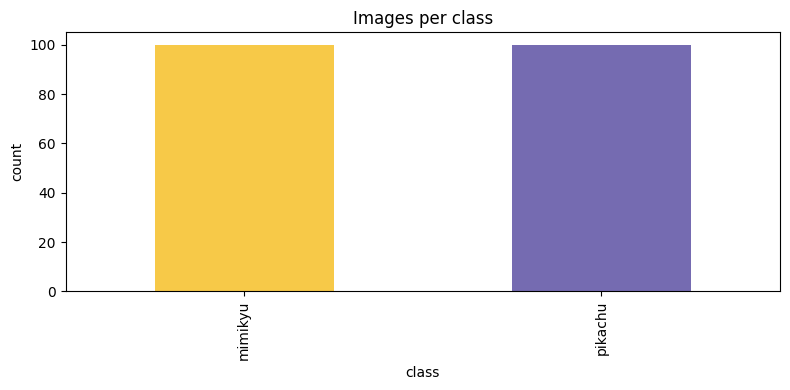

In [17]:
# 允許的影像附檔名
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# 檢查類別資料夾是否存在
missing = [c for c in TARGET_CLASSES if not (RAW_DIR / c).exists()]
if missing:
    raise FileNotFoundError(f"以下類別資料夾不存在：{missing}，請確認 RAW_DIR={RAW_DIR}")

# 掃描兩個類別（白名單），遞迴抓圖
records = []
for cls in sorted(TARGET_CLASSES):
    class_dir = RAW_DIR / cls
    for p in class_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            records.append({"class": cls, "path": str(p.resolve())})

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError(f"在 {RAW_DIR} 底下沒有找到影像，請確認結構：{RAW_DIR}/<mimikyu|pikachu>/image.xxx")

# 統計 & 繪圖
counts = df["class"].value_counts().sort_index()
print("各類別圖片數量：")
display(counts)

ax = counts.plot(kind="bar", figsize=(8, 4), color=["#F7C948", "#756BB1"])
ax.set_title("Images per class")
ax.set_ylabel("count")
ax.set_xlabel("class")
plt.tight_layout()
plt.show()

(2) 由單一資料來源目錄（/datasets/<class>/...）切成 80% train、剩下 20% 再對半分成 10% val / 10% test，並把檔案複製到 TRAIN_DIR / VAL_DIR / TEST_DIR

In [30]:
# ---------------------------
# (B) 依類別分群 → 80%/10%/10% 切割 → 複製到 train/val/test
# ---------------------------
rng = np.random.default_rng(SEED)
splits = []

for cls, g in df.groupby("class"):
    # 以固定種子打亂
    g_shuf = g.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n = len(g_shuf)
    n_train = int(np.floor(0.8 * n))
    remaining = n - n_train
    n_val = remaining // 2
    n_test = remaining - n_val  # 確保總和為 n

    # 指派 split 標籤
    g_shuf.loc[: n_train - 1, "split"] = "train"
    g_shuf.loc[n_train : n_train + n_val - 1, "split"] = "val"
    g_shuf.loc[n_train + n_val :, "split"] = "test"

    splits.append(g_shuf)

split_df = pd.concat(splits, ignore_index=True)

# 建立目標資料夾
for split in ["train", "val", "test"]:
    for cls in split_df.loc[split_df["split"] == split, "class"].unique():
        Path(DATA_DIR, split, cls).mkdir(parents=True, exist_ok=True)

# 複製檔案到對應 split 目錄
print("開始複製檔案到 train/val/test ...")
for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    src = Path(row["path"])
    dst = Path(DATA_DIR, row["split"], row["class"], src.name)
    if not dst.exists():  # 避免重複覆寫
        try:
            copy2(src, dst)
        except Exception as e:
            print(f"複製失敗：{src} → {dst}，原因：{e}")

# 切割後的統計
post_counts = (
    split_df.groupby(["split", "class"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
)
print("\n切割後各 split / class 的數量表：")
display(post_counts)

開始複製檔案到 train/val/test ...


100%|██████████| 200/200 [00:00<00:00, 2397.36it/s]


切割後各 split / class 的數量表：


class,mimikyu,pikachu
split,,
test,10,10
train,80,80
val,10,10


In [19]:
import tensorflow as tf, numpy as np, cv2

print("TF:", tf.__version__)      # 期望 2.19.0
print("NumPy:", np.__version__)   # 2.x
print("OpenCV:", cv2.__version__) # 4.12+（headless 版也行）

TF: 2.19.0
NumPy: 2.0.2
OpenCV: 4.12.0


In [20]:
# ========= Mimikyu vs. Pikachu 影像分類（Keras / EfficientNetB0）=========
# 載入套件
import os, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from PIL import Image

In [21]:
# %% 設定參數與路徑
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Project_Pokemon-Mimikyu-TorchDetect/datasets"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

IMG_SIZE = (224, 224)
BATCH    = 32
EPOCHS   = 20
SEED     = 42

In [22]:
# 建立 Dataset（含 class_names 印出）
# label_mode 要用 "int"
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode="int", image_size=IMG_SIZE, batch_size=BATCH,
    shuffle=True, seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode="int", image_size=IMG_SIZE, batch_size=BATCH,
    shuffle=False
)

Found 192 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [23]:
# 顯示類別順序
class_names = train_ds.class_names
print("類別順序 (class_names):", class_names)
# 範例輸出：['mimikyu', 'pikachu']

類別順序 (class_names): ['mimikyu', 'pikachu']


In [24]:
# ====== 在這裡加上 AUTOTUNE 優化 ======
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
# ======================================

In [25]:
# 檢查訓練資料的類別分布
total_counts = {name: 0 for name in class_names}
for _, labels in train_ds.unbatch():
    total_counts[class_names[int(labels.numpy())]] += 1
print("類別分布：", total_counts)

類別分布： {'mimikyu': 96, 'pikachu': 96}


In [26]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# 建立模型（EfficientNetB0）
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
], name="data_augmentation")

base = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# x = layers.Rescaling(1./255)(x)
x = layers.Lambda(preprocess_input)(x)  # 會把輸入轉成 EfficientNet 預期的尺度
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

# 模型輸出 & compile：
# 輸出層
# outputs = layers.Dense(1, activation="sigmoid")(x)  # 換掉
outputs = layers.Dense(2, activation="softmax")(x)     # 兩類softmax
model = keras.Model(inputs, outputs)

# ★ 重點：from_logits=False（或省略）
# model.compile(optimizer=keras.optimizers.Adam(1e-3),
#               loss="binary_crossentropy",
#               metrics=["accuracy", keras.metrics.AUC(name="auc")])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]   # 先把 AUC 拿掉
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [27]:
# 訓練（階段一：凍結 backbone）
ckpt_path = "./weights/efficientnetb0_mimikyu_pikachu.weights.h5"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, save_weights_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6088 - loss: 0.7226
Epoch 1: val_accuracy improved from -inf to 0.85000, saving model to ./weights/efficientnetb0_mimikyu_pikachu.weights.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.6118 - loss: 0.7168 - val_accuracy: 0.8500 - val_loss: 0.5363
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7067 - loss: 0.6030
Epoch 2: val_accuracy improved from 0.85000 to 0.95000, saving model to ./weights/efficientnetb0_mimikyu_pikachu.weights.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.7106 - loss: 0.5961 - val_accuracy: 0.9500 - val_loss: 0.3658
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8785 - loss: 0.3953
Epoch 3: val_accuracy did not improve from 0.95000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8787 - loss: 0.3937 - val_accuracy: 0.9500 - val_loss: 0.2649
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9015 - loss: 0.3170
Epoch 4: val_accuracy improved

In [28]:
# 訓練（階段二：微調最後幾層）
base.trainable = True

# for layer in base.layers[:-50]:
#     layer.trainable = False

# 凍結 BatchNorm 層
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 只訓練後段卷積
for layer in base.layers[:-50]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


# model.compile(optimizer=keras.optimizers.Adam(1e-4),
#               loss="binary_crossentropy",
#               metrics=["accuracy", keras.metrics.AUC(name="auc")])

# model.compile(
#     optimizer=keras.optimizers.Adam(1e-5),
#     loss=model.loss,  # 沿用之前設定
#     metrics=model.metrics
# )

auc_metric = tf.keras.metrics.AUC(name="auc")

def auc_pikachu(y_true, y_pred):
    # y_true: (batch,) int；y_pred: (batch, 2) softmax
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=2)
    return auc_metric(y_true_oh[:,1], y_pred[:,1])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy", auc_pikachu]
)

model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9135 - auc_pikachu: 0.9687 - loss: 0.3096 
Epoch 1: val_accuracy did not improve from 1.00000
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 701ms/step - accuracy: 0.9118 - auc_pikachu: 0.9666 - loss: 0.3096 - val_accuracy: 1.0000 - val_auc_pikachu: 0.9638 - val_loss: 0.0267
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9951 - auc_pikachu: 0.9757 - loss: 0.0269
Epoch 2: val_accuracy did not improve from 1.00000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9950 - auc_pikachu: 0.9762 - loss: 0.0260 - val_accuracy: 1.0000 - val_auc_pikachu: 0.9880 - val_loss: 0.0076
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - auc_pikachu: 0.9903 - loss: 0.0192
Epoch 3: val_accuracy did not improve from 1.00000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 1.0000 - auc_pikachu: 0.9904 - loss: 0.0187 - val_accuracy: 1.0000 - val_auc_pikachu: 0.9936 - val_loss: 0.0056
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81

In [29]:
# 載入最佳權重
model.load_weights(ckpt_path)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 52 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
import numpy as np
from sklearn.metrics import roc_curve, classification_report, confusion_matrix

# 根據 class_names 找出「正類」(pos) 的索引；這裡假設我們把 pikachu 視為正類
pos_name = "pikachu"
pos_idx = class_names.index(pos_name)   # 通常會是 1，如果 class_names=['mimikyu','pikachu']

y_prob, y_true = [], []
for imgs, labs in val_ds:
    preds = model.predict(imgs, verbose=0)   # shape: (batch, 2) softmax 機率
    p = preds[:, pos_idx]                    # 只取正類(pikachu)的機率 → shape: (batch,)
    y_prob.append(p)
    y_true.append(labs.numpy().ravel())      # label_mode="int" ⇒ shape: (batch,)

y_prob = np.concatenate(y_prob)
y_true = np.concatenate(y_true).astype(int)

# 以 Youden's J（tpr - fpr）找最佳門檻
fpr, tpr, thr = roc_curve(y_true, y_prob, pos_label=1)
best_idx = np.argmax(tpr - fpr)
best_thr = thr[best_idx]
print(f"🌟 最佳門檻 best_thr = {best_thr:.3f}")

# 在最佳門檻下的效能
y_pred = (y_prob >= best_thr).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

🌟 最佳門檻 best_thr = 0.513
Confusion Matrix:
 [[20  0]
 [ 0 20]]
              precision    recall  f1-score   support

     mimikyu       1.00      1.00      1.00        20
     pikachu       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
# 驗證模型是否預測正確類別
# 以最佳門檻檢視一個 batch（sigmoid 版本）
best_thr = 0.5  # 預設，建議先用上面整個 val_ds 求出 best_thr 再塞進來

for images, labels in val_ds.take(1):
    probs = model.predict(images, verbose=0).ravel()  # (batch,)
    for i in range(len(images)):
        prob  = float(probs[i])
        pred_idx = int(prob >= best_thr)              # 1= pikachu
        true_idx = int(np.squeeze(labels[i].numpy()).astype("int32"))
        print(f"真實:{class_names[true_idx]:8s} | 預測:{class_names[pred_idx]:8s} | pikachu機率={prob:.3f} | thr={best_thr:.3f}")

真實:mimikyu  | 預測:pikachu  | pikachu機率=0.885 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.115 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.879 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.121 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.854 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.146 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.909 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.091 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.945 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.055 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.922 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.078 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.807 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.193 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.946 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.054 | thr=0.500
真實:mimikyu  | 預測:pikachu  | pikachu機率=0.919 | thr=0.500
真實:mimikyu  | 預測:mimikyu  | pikachu機率=0.081 | th

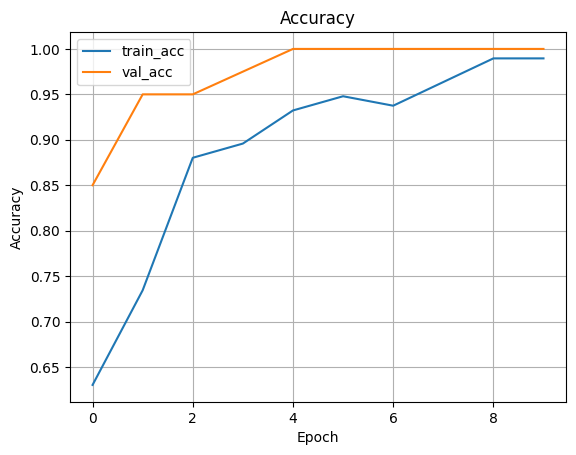

In [ ]:
# 檢查模型沒有學好（訓練失敗）
# 檢查方式：
# 請印出訓練與驗證的 accuracy：

# 若：
# train_acc ≈ 0.6、val_acc ≈ 0.6 → 模型沒學會
# train_acc 很高、val_acc 很低 → 過擬合或資料不平衡

import matplotlib.pyplot as plt

# X軸顯示Epoch、Y軸顯示Accuracy

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel("Epoch")                # X 軸名稱
plt.ylabel("Accuracy")              # Y 軸名稱
plt.legend()
plt.grid()
plt.title("Accuracy")
plt.show()


In [35]:
# 下面這段會自動抽樣多張圖片、一次批量推論，並用網格顯示每張圖的「預測類別與置信度」，同時（若能從父資料夾判斷到真實標籤）也會在標題附上 GT=真實類別，正確/錯誤分別用綠/紅色標示。

import math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def _collect_images_from(root_dir: Path, class_names):
    """從 root_dir/<class>/... 收集影像路徑，只收 class_names 列出的類別。"""
    paths = []
    for cls in class_names:
        cls_dir = root_dir / cls
        if cls_dir.exists():
            paths += [p for p in cls_dir.rglob("*")
                      if p.is_file() and p.suffix.lower() in IMG_EXTS]
    return paths

def sample_and_show_grid(sample_count=12, prefer_split="test", cols=4, seed=42):
    """
    依優先順序(test→val→train→RAW_DIR)抽樣 sample_count 張圖，
    批量推論並以網格顯示 (預測/信心/真值)。
    """
    # 1) 決定抽樣來源
    split_order = [prefer_split] + [s for s in ["test", "val", "train"] if s != prefer_split]
    root_dir = None
    for sp in split_order:
        d = Path(DATA_DIR) / sp
        if d.exists() and any(d.iterdir()):
            root_dir = d
            break
    if root_dir is None:
        root_dir = Path(RAW_DIR)  # 退回原始資料夾 (pokemon/mimikyu|pikachu)

    # 2) 收集候選圖片並抽樣
    all_paths = _collect_images_from(root_dir, class_names)
    if not all_paths:
        raise RuntimeError(f"在 {root_dir} 底下找不到影像（類別={class_names}）。")

    random.seed(seed)
    sample_paths = random.sample(all_paths, min(sample_count, len(all_paths)))

    # 3) 讀圖 + 前處理（批量）
    imgs_pil, batch = [], []
    for p in sample_paths:
        img = Image.open(p).convert("RGB").resize(IMG_SIZE)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        imgs_pil.append(img)
        batch.append(arr)
    batch = np.stack(batch, axis=0)  # (N, H, W, 3)

    # 4) 批量推論（此版對應 sigmoid 單輸出）
    # probs1 = model.predict(batch, verbose=0).reshape(-1)  # sigmoid 輸出對應 label=1 的機率
    # pred_idx = (probs1 >= 0.5).astype(int)
    # pred_names = [class_names[i] for i in pred_idx]
    # confs = [float(p if i == 1 else 1 - p) for p, i in zip(probs1, pred_idx)]

    # 4) 批量推論（若你是 softmax 二輸出（Dense(2,"softmax")），改用以下三行取機率與預測：
    preds = model.predict(batch, verbose=0)             # (N, 2)
    pos_idx = class_names.index("pikachu")              # 或你定義的正類
    pred_idx = np.argmax(preds, axis=1); pred_names = [class_names[i] for i in pred_idx]; confs = preds[np.arange(len(preds)), pred_idx]


    # 5) 計算 (若能推得 GT) 正確與否
    gts = []
    correct = []
    for p, pn in zip(sample_paths, pred_names):
        gt = p.parent.name if p.parent.name in class_names else None
        gts.append(gt)
        correct.append((gt is None) or (pn == gt))  # 若無法判斷 GT，就不算錯

    # 6) 視覺化：網格
    n = len(sample_paths)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.atleast_2d(axes)
    for i, (ax, img, pn, cf, pth, ok, gt) in enumerate(
        zip(axes.flat, imgs_pil, pred_names, confs, sample_paths, correct, gts)
    ):
        ax.imshow(img)
        ax.axis("off")
        title_color = "green" if ok else "red"
        if gt is not None:
            ax.set_title(f"{pth.name}\nPred: {pn}  conf={cf:.3f}  |  GT: {gt}",
                         color=title_color, fontsize=10)
        else:
            ax.set_title(f"{pth.name}\nPred: {pn}  conf={cf:.3f}",
                         color=title_color, fontsize=10)

    # 把多餘的小格清空
    for j in range(i+1, rows*cols):
        axes.flat[j].axis("off")
    plt.tight_layout()
    plt.show()

    # 8) 簡單統計
    if any(g is not None for g in gts):
        total_eval = sum(g is not None for g in gts)
        acc = sum((pn == gt) for pn, gt in zip(pred_names, gts) if gt is not None) / total_eval
        print(f"本次抽樣可評估 {total_eval} 張，整體準確率：{acc:.3%}")
    else:
        print("此次抽樣無法推得真實標籤（GT），僅顯示預測與信心。")


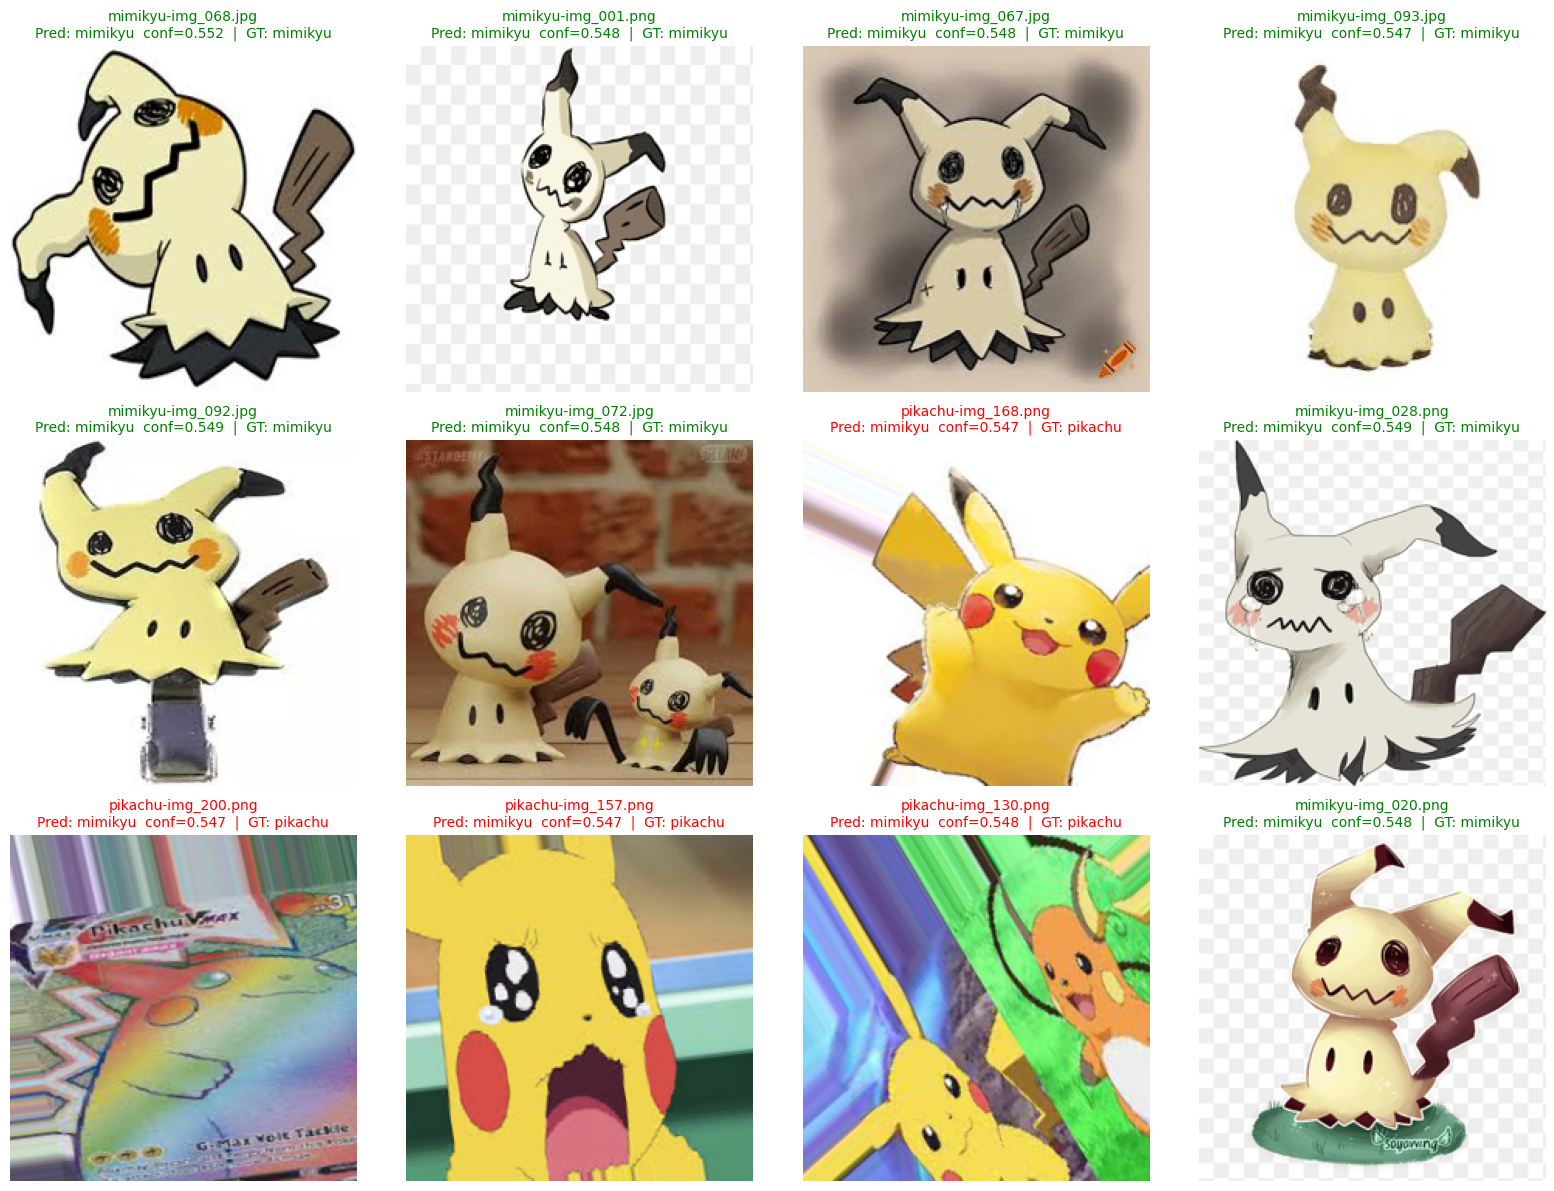

本次抽樣可評估 12 張，整體準確率：66.667%


In [36]:
# ===== 使用範例 =====
# 從 test 集抽 12 張、4 欄展示
sample_and_show_grid(sample_count=12, prefer_split="test", cols=4, seed=42)